<h1>The White Wine Dataset</h1>

The white wine data is available in 
<a> https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv </a>

In [1]:
import pandas as pd
from logger import get_logger

logger = get_logger(__name__)

logger.debug("Logging verified")

white_wine_df = pd.read_csv("data/winequality-white.csv", sep=";")

DEBUG: Logging verified


In [2]:
white_wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [3]:
white_wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


In [4]:
white_wine_df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

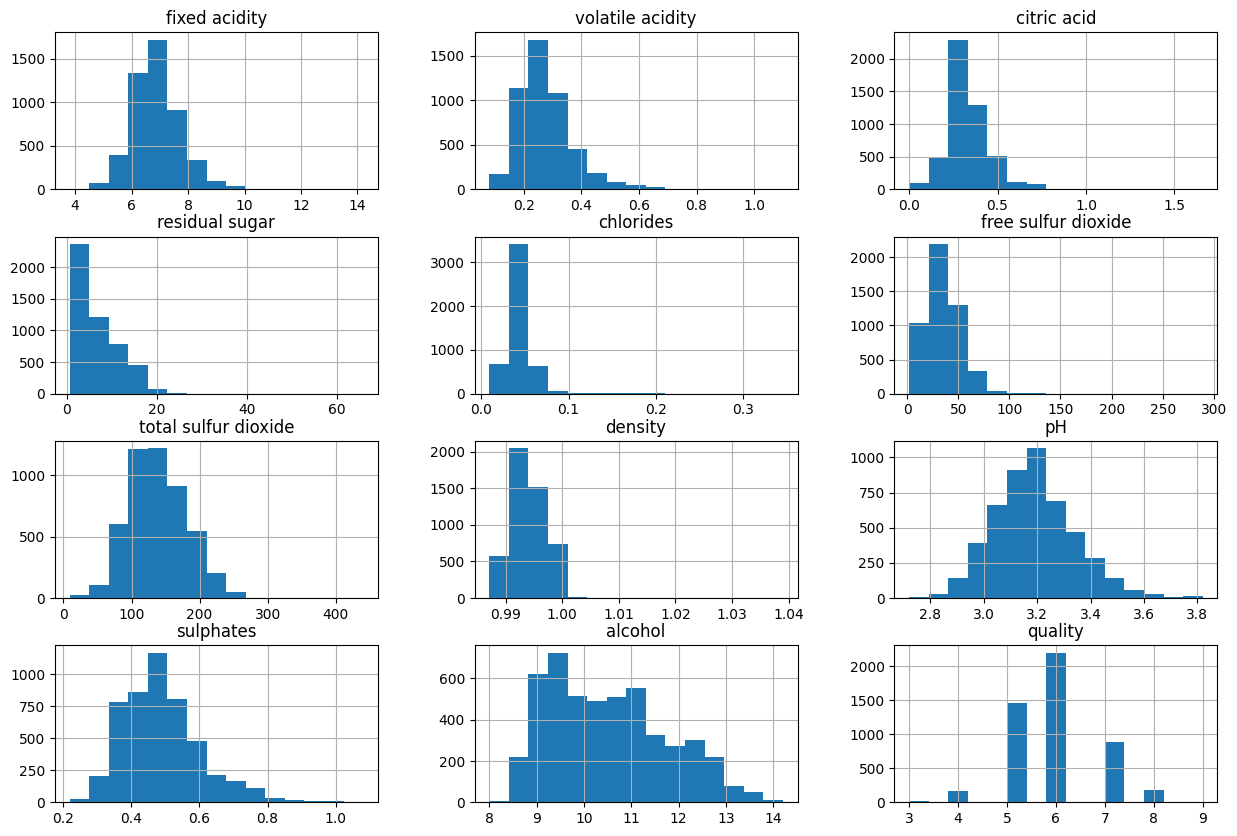

In [5]:
white_wine_df.hist(bins = 15, figsize=(15,10))

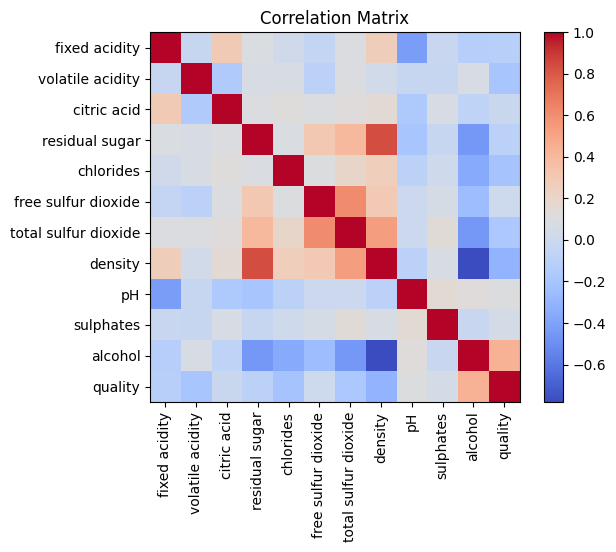

In [6]:
from utils.evaluation_metrics import plot_correlation_matrix

plot_correlation_matrix(white_wine_df)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

x = white_wine_df.drop('quality', axis=1)
y = white_wine_df['quality']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), x.columns)
    ]
)

x_train_preprocessed = preprocessing_pipeline.fit_transform(x_train)
x_test_preprocessed = preprocessing_pipeline.transform(x_test)

le = LabelEncoder()

y_train_preprocessed = le.fit_transform(y_train)
y_test_preprocessed = le.transform(y_test)

logger.info("Data preprocessing completed. The code has applied only StandardScaler to all the columns as every columns are numerical.")

INFO: Data preprocessing completed. The code has applied only StandardScaler to all the columns as every columns are numerical.


In [8]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

logger.info(f"Using device: {device}")

INFO: Using device: cuda


In [9]:
x_train_tensor = torch.tensor(x_train_preprocessed, dtype=torch.float)
y_train_tensor = torch.tensor(y_train_preprocessed, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_preprocessed, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test_preprocessed, dtype=torch.long).to(device)

# these create a new tensor from the data provided

In [10]:
from torch import nn
from torch import Tensor

class WhiteWineQualityModel_0(nn.Module):
    r"""
        This class is a simple feed forward neural network for the white wine quality data.
    """
    def __init__(
            self, 
            input_dim: int, 
            output_dim: int
        ) -> None:
        r"""
        Initialize the model architecture (constructor)
    
        Args:
            input_dim (int) -> Number of input features (columns)
            output_dim (int) -> Number of output classes

        Returns:
            None
        """
        
        super().__init__()

        self.input_layer = nn.Linear(in_features=input_dim, out_features=33) # we have 11 features and 1 label. We are taking 3 times the input features as hidden units 
        self.hidden_layer_1 = nn.Linear(in_features=33, out_features=33)
        self.hidden_layer_2 = nn.Linear(in_features=33, out_features=33)
        self.hidden_layer_3 = nn.Linear(in_features=33, out_features=33)
        self.output_layer = nn.Linear(in_features=33, out_features=output_dim) # output layer will have 6 unit for the final 1 label.
        self.relu = nn.ReLU()

        self.dropout = nn.Dropout(p=0)

    def forward(
            self, 
            x: Tensor
        ) -> Tensor:
        r""" 
        holds the forward pass logic
        
        Args :
            x (torch.Tensor) -> input feature tensor

        Returns:
            torch.Tensor -> Predicted logits (raw scores) for each other
        """
        
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_3(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output_layer(x)

        return x
    

2026-01-23 19:50:58,988	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-01-23 19:50:59,093	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
INFO: Epoch : 0 
	Train Loss : 1.6563811052230097 
	Test Loss : 1.3317229747772217 
	Accuracy : 0.44081631302833557

INFO: Epoch : 10 
	Train Loss : 1.0232926876314226 
	Test Loss : 1.0623029470443726 
	Accuracy : 0.5397958755493164

INFO: Epoch : 20 
	Train Loss : 0.9751453880340822 
	Test Loss : 1.0220524072647095 
	Accuracy : 0.5622448921203613

INFO: Epoch : 30 
	Train Loss : 0.9445873950758288 
	Test Loss : 1.023119330406189 
	Accuracy : 0.5612244606018066

INFO: Epoch : 40 
	Train Loss : 0.9141851615521216 
	Test Loss : 1.0608762502670288 
	Accuracy : 0.545918345451355

INFO: Epoch : 50 
	Train Loss : 0.8992634002239474 
	Test Loss : 1.0352653264

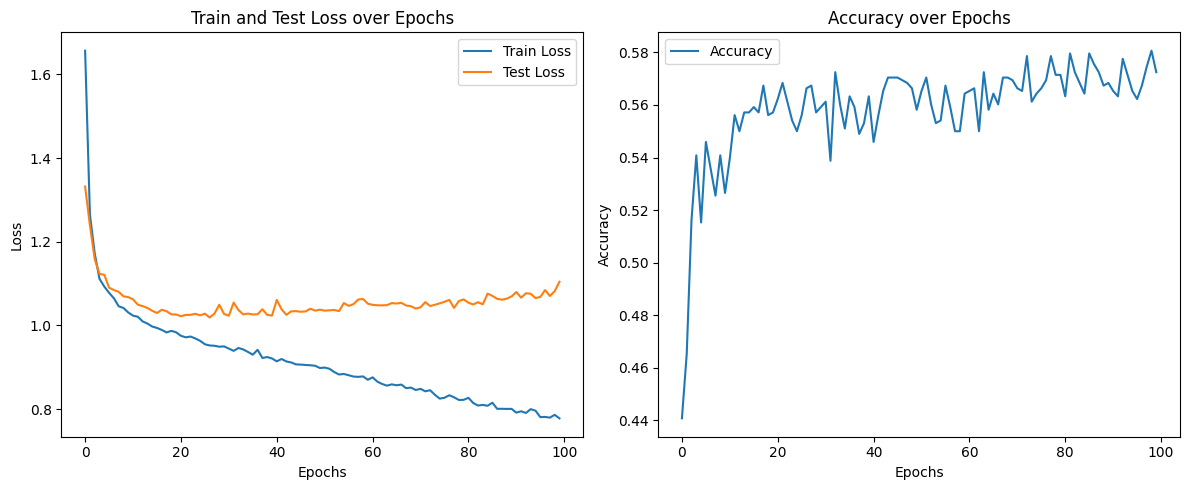

INFO: Training completed. Best accuracy achieved: 0.5806122422218323


In [11]:
r"""
Training the model and logging the training parameters and evaluation metrics to `wine_quality/results`
Plotting 
"""

from utils.training_utils import train_dataset_v0

model_0 = WhiteWineQualityModel_0(input_dim=11, output_dim=7).to(device)

epochs = 100
lr = 0.001
optimizer = torch.optim.Adam(model_0.parameters(), lr = lr)
loss_fn = nn.CrossEntropyLoss()

logs_filename = "results/wine_quality_results.csv"
trained_model, best_accuracy = train_dataset_v0(model= model_0,
                 x_train_tensor=x_train_tensor,
                 y_train_tensor=y_train_tensor,
                 x_test_tensor=x_test_tensor,
                 y_test_tensor=y_test_tensor,
                 optimizer=optimizer,
                 loss_function=loss_fn,
                 epochs=epochs,
                 device=device,
                 log_file=logs_filename,
                 batch_size=64,
                 plots_folder_path="white_wine_result_figures")

logger.info(f"Training completed. Best accuracy achieved: {best_accuracy}")

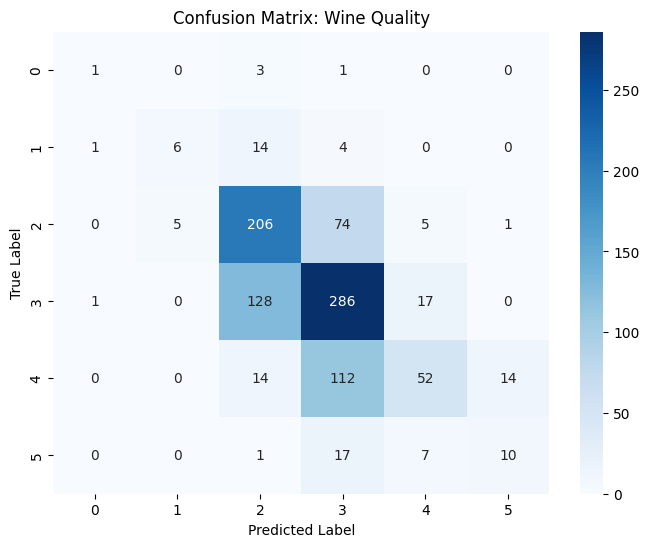

In [12]:
from utils.evaluation_metrics import plot_confusion_matrix

trained_model.eval()

with torch.inference_mode():
    y_logits = trained_model(x_test_tensor)
    y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

plot_confusion_matrix(y_test_tensor, y_preds)

In [13]:
accuracy = (y_preds == y_test_tensor).sum().item() / len(y_test_tensor)
logger.info(f"Test Accuracy: {accuracy * 100:.2f}%")

INFO: Test Accuracy: 57.24%


In [15]:
"""
Tune is a Python library for experiment execution and hyperparameter tuning at any scale.
We are tuning with the learning rate, batch size, optimizer and epochs - any other hyperparameters shall be added if needed

the below tuner can be used if entire process shall be processed in cpu itself, if gpu computation is needed we need to add with_reources function to the tuner

the code for separating tasks to both cpu and gpu or gpu only is commented in the next cell 
"""

import torch.optim as optim
from ray.tune import with_parameters, with_resources
from ray import tune, train
from utils.training_utils import ray_tune_wrapper
import os

current_project_path = os.getcwd()
os.makedirs("white_wine_ray_tune_results",exist_ok=True)
custom_storage_path = os.path.join(current_project_path,"white_wine_ray_tune_results")

tuning_model_class = WhiteWineQualityModel_0

search_space = {
    "lr" : tune.loguniform(1e-4,1e-1),
    "batch_size" : tune.choice([16,32, 64]),
    "optimizer" : tune.choice([optim.Adam, optim.SGD, optim.NAdam, optim.Adadelta, optim.RMSprop]),
    "epochs" : tune.choice([100, 300, 500])
}

tuner = tune.Tuner(
    with_parameters(
        ray_tune_wrapper,
        model_class=tuning_model_class,
        x_train_tensor=x_train_tensor.cpu(),
        y_train_tensor=y_train_tensor.cpu(),
        x_test_tensor=x_test_tensor.cpu(),
        y_test_tensor=y_test_tensor.cpu(),
        input_dim = 11,
        output_dim = 7,
        log_file = "white_wine_ray_tune/ray_tune_logs.txt"
    ),
    param_space=search_space,
    tune_config= tune.TuneConfig(
        metric = "accuracy",
        mode = "max",
        num_samples = 10
    ),
    run_config= tune.RunConfig(
        name="wine_quality_experiment",
        storage_path=custom_storage_path,
        verbose =1
    )
)

results = tuner.fit()
best_results = results.get_best_result(metric= "accuracy", mode="max")
logger.info(f"Best Config : { best_results.config }")

df = results.get_dataframe()
path ="white_wine_ray_tune/tuning_results.csv"

if  not os.path.exists(os.path.dirname(path)):
    os.makedirs(os.path.dirname(path))
df.to_csv(path,mode = 'a', index=True , header=not os.path.isfile(path))

(ray_tune_wrapper pid=96702) INFO: device : cpu
2026-01-23 19:55:33,959	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'optimizer': ('__ref_ph', '7bdb82fb')}
2026-01-23 19:55:35,129	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'optimizer': ('__ref_ph', '3bb169ff')}
2026-01-23 19:55:35,587	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'optimizer': ('__ref_ph', '7bdb82fb')}
2026-01-23 19:55:42,880	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'optimizer': ('__ref_ph', '7bdb82fb')}
2026-01-23 19:56:16,666	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'optimizer': ('__ref_ph', '7bdb82fb')}
2026-01-23 19:56:20,390	INFO tensorboardx.py:308 -- Removed the following hyperparameter values when logging to tensorboard: {'